# TP Coding a GAN in Pytorch

Author : Alasdair Newson

alasdair.newson@telecom-paris.fr

## Objective:

The goal of this TP is to explore GANs applied to the mnist (and possibly cifar10) datasets.

We will start with the mnist dataset.

### Your task:
You need to add the missing parts in the code (parts between # --- START CODE HERE and # --- END CODE HERE or # FILL IN CODE)

First of all, let's load some packages

In [ ]:

import matplotlib.pyplot as plt
import sys
import numpy as np
import pickle
import copy
import os
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image

def pytorch_to_numpy(x):
  return x.detach().numpy()


# Decide which device we want to run on
if (torch.cuda.is_available()):
  device = torch.device("cuda:0")
else:
  device = "cpu"


## Loading the data

We define a function to load the mnist or cifar10 datasets. Note, we normalise the data between -1 and 1 here (this is often the case for GANs).

In [ ]:
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,),(0.5,)),
])

# MNIST Dataset
mnist_trainset = datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
mnist_testset = datasets.MNIST(root='./mnist_data/', train=False, transform=transform, download=False)

#create data loader with smaller dataset size
max_mnist_size = 1000
mnist_trainset_reduced = torch.utils.data.random_split(mnist_trainset, [max_mnist_size, len(mnist_trainset)-max_mnist_size])[0]
mnist_train_loader = torch.utils.data.DataLoader(mnist_trainset_reduced, batch_size=64, shuffle=True)

# download test dataset
max_mnist_size = 512
mnist_testset_reduced = torch.utils.data.random_split(mnist_testset, [max_mnist_size, len(mnist_testset)-max_mnist_size])[0]
mnist_test_loader = torch.utils.data.DataLoader(mnist_testset_reduced, batch_size=64, shuffle=True)



100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.58MB/s]


In [ ]:
n_rows = mnist_trainset_reduced.dataset.train_data.shape[1]
n_cols = mnist_trainset_reduced.dataset.train_data.shape[2]
n_channels = 1
n_pixels = n_rows*n_cols

img_shape = (n_rows, n_cols, n_channels)

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


## GAN parameters

In [ ]:

## GAN parameters
z_dim = 10
batch_size = 64
## parameters for training
n_epochs = 400
n_iters_inner=1	#number of internal loops
sample_interval=100
# Learning rate for optimizers
lr = 0.0002
beta_1 = 0.5

# hidden dimensions : careful, the order here is with respect to the generator, and the discriminator is in the opposite order
h_dim_1 = 256
h_dim_2 = 512

## Model architecture

Now, we define the model architecture.

For the first dataset, mnist, we are going to use fully connected layers. Implement the following architecture, for the generator and the discriminator :

Generator :
- Dense layer, to size 256
- Leaky ReLU ($\alpha=0.2$)
- Dense layer, to size 512
- Leaky ReLU ($\alpha=0.2$)
- Dense layer, output size 784
- Tanh activation
- Reshape to size $28 \times 28 \times 1$

Discriminator :
- Flatten
- Dense layer, to size 512
- Leaky ReLU ($\alpha=0.2$)
- Dense layer, output size 256
- Leaky ReLU ($\alpha=0.2$)
- Dense layer, output size 1
- Sigmoid activation

In [ ]:
# Generator Code

class Generator(nn.Module):
  def __init__(self, z_dim, h_dim_1, h_dim_2, n_rows,n_cols,n_channels):
    super(Generator, self).__init__()
    self.n_rows = n_rows
    self.n_cols = n_cols
    self.n_channels = n_channels
    self.n_pixels = (self.n_rows)*(self.n_cols)
    self.h_dim_1 = h_dim_1
    self.h_dim_2 = h_dim_2
    self.z_dim = z_dim

    # START TO FILL IN
    self.fc1 = nn.Linear(self.z_dim, self.h_dim_1)
    self.fc2 = nn.Linear(self.h_dim_1, self.h_dim_2)
    self.fc3 = nn.Linear(self.h_dim_2, self.n_pixels)
    # END TO FILL IN

  def forward(self, z):
    # START TO FILL IN
    y_1 = self.fc1(z)
    y_1 = F.leaky_relu(y_1, 0.2)
    y_2 = self.fc2(y_1)
    y_2 = F.leaky_relu(y_2, 0.2)
    y_3 = self.fc3(y_2)
    y = torch.tanh(y_3)
    return y.view(-1, self.n_channels, self.n_rows, self.n_cols)
    # END TO FILL IN


In [ ]:
class Discriminator(nn.Module):
  def __init__(self, h_dim_2, h_dim_1, z_dim, n_rows,n_cols,n_channels):
    super(Discriminator, self).__init__()

    self.n_rows = n_rows
    self.n_cols = n_cols
    self.n_channels = n_channels
    self.n_pixels = (self.n_rows)*(self.n_cols)
    self.h_dim_1 = h_dim_1
    self.h_dim_2 = h_dim_2
    self.z_dim = z_dim

    # START TO FILL IN
    self.fc1 = nn.Linear(self.n_pixels, self.h_dim_2)
    self.fc2 = nn.Linear(self.h_dim_2, self.h_dim_1)
    self.fc3 = nn.Linear(self.h_dim_1, 1)
    # END TO FILL IN

  def forward(self, x):
    y_1 = self.fc1(x.view(x.size(0), -1)) # FILL IN HERE
    y_1 = F.leaky_relu(y_1, 0.2)
    y_2 = self.fc2(y_1)
    y_2 = F.leaky_relu(y_2, 0.2)
    y_3 = self.fc3(y_2)
    y = torch.sigmoid(y_3)
    return y

Create generator and discriminator

In [ ]:
gen_model = Generator(z_dim, h_dim_1, h_dim_2, n_rows, n_cols, n_channels).to(device) # FILL IN HERE
# Print the model
print(gen_model)

disc_model = Discriminator(h_dim_2, h_dim_1, z_dim, n_rows, n_cols, n_channels).to(device) # FILL IN HERE, CAREFUL OF ORDER OF PARAMETERS
# Print the model
print(disc_model)

Generator(
  (fc1): Linear(in_features=10, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=784, bias=True)
)
Discriminator(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1, bias=True)
)


## Loss function


The GAN loss function is the following :
\begin{equation}
	\min_{G} \max_{D} \mathbb{E}_{x \in p_{data}} \left[ \log D(x)\right] +
	\mathbb{E}_{z \in p_{z}}\left[ \log \left( 1 - D(G(z)) \right)\right],
\end{equation}
where $G$ is the generator, $D$ is the discriminator, $z$ is the latent code, which follows a normal distribution.

You should notice that this is extremely similar to the binary cross-entropy function. Therefore, there is an intelligent way to train the discriminator : we give it first a batch of real images, and label them as real, and secondly we give a batch of fake images and label them as fake. Therefore, the discriminator training itself is done in two sequential steps (first true, then fake). If the labels are correctly chosen (further on, during training), you can (and __should__) use the binary cross-entropy function.

The generator loss, however, must be specified as :
- $mean(\log(1-D(G(z))))$

You can use the ```torch.mean``` function for this purpose.


The training is carried out sequentially : first we execute a few training steps on the discriminator, and then one on the generator. Therefore, we use two loops : one to train the discriminator (the internal loop) and one to train the generator (external loop, ie. the number of epochs). The GAN training algorithm is as follows :

- For $i=0$ to $n-1$
  - For $j=0$ to $m-1$
    - $x \leftarrow$ random batch of data
    - $z \leftarrow$ random batch of latent codes
    - Train discriminator on real images $x$
    - Train discriminator on fake images $G(z)$
  - $z \leftarrow$ random batch of latent codes
  - Train discriminator on fake images $G(z)$



In [ ]:

# Setup Adam optimizers for both G and D
optimizer_disc = optim.Adam(disc_model.parameters(), lr=lr, betas=(beta_1, 0.999))
optimizer_gen = optim.Adam(gen_model.parameters(), lr=lr, betas=(beta_1, 0.999))

# criterion used for the discriminator loss
bce_criterion = nn.BCELoss()  # FILL IN CODE

# criterion used for the generator loss
def loss_fn_gen(d_gen_data):
  loss_gen =  torch.mean(torch.log(1 - d_gen_data))  # FILL IN CODE
  return loss_gen



### Sampling function

We now create a function to sample several images during training (to follow the convergence of the network)

In [ ]:

def sample_images(generator,z_dim, rand_seed=30):
  #np.random.seed(rand_seed)
  r, c = 5, 5
  z_random = torch.randn(r * c, 1, z_dim, dtype=torch.float, device=device) #np.random.normal(0, 1, (r * c, z_dim))

  gen_imgs = np.transpose( generator(z_random).cpu().detach().numpy() , (0,2,3,1))

  # Rescale images 0 - 1
  gen_imgs = 0.5 * gen_imgs + 0.5

  fig, axs = plt.subplots(r, c)
  cnt = 0
  for i in range(r):
    for j in range(c):
      #black and white images
      if(gen_imgs.shape[3] == 1):
        axs[i,j].imshow(gen_imgs[cnt,:,:,0], cmap='gray')
      elif(gen_imgs.shape[3] == 3):   #colour images
        gen_imgs_temp = gen_imgs.copy()
        gen_imgs_temp = 255.*np.clip(gen_imgs_temp,0.0,1.0)
        axs[i,j].imshow(gen_imgs_temp[cnt, :,:,:].astype(np.uint8))
      else:
        print('Error, unsupported channel size. Dude, I don''t know what you want me to do.\
            I can''t handle this data. You''ve made me very sad ...')
      axs[i,j].axis('off')
      cnt += 1
  plt.show()

## Training

We are now ready to train the network. Here is the training algorithm again :

- For $i=0$ to $n_{epochs}-1$
  - For $j=0$ to $n_{iters\_inner}-1$
    - $x \leftarrow$ random batch of data
    - $z \leftarrow$ random batch of latent codes
    - Train discriminator on real images $x$
    - Train discriminator on fake images $G(z)$
  - $z \leftarrow$ random batch of latent codes
  - Train discriminator on fake images $G(z)$

You can use ```torch.randn``` to create a batch of random Gaussian latent codes:
- ```torch.randn(dim_1, dim_2, dim_3, device=device)```
where ```dim_1, dim_2, dim_3``` are the dimensions of the Tensor.

To create a batch of labels equal to 1, use the following function:
- ```torch.ones(my_shape, dtype=torch.float, device=device)```
where ```my_shape``` is the shape of the tensor of ones that you wish.

Similarly, to create a batch of zeros, use:
- ```torch.zeros(my_shape, dtype=torch.float, device=device)```

In [ ]:
print(device)

cpu


Starting Training
[0/400][0/16] 	Loss_D: 1.4565	Loss_G: -0.6752	D(x): 0.4587	D(G(z)): 0.4918


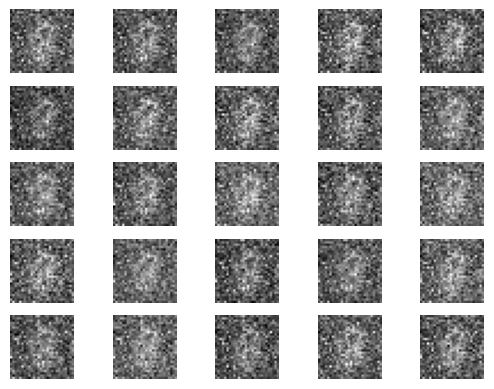

[1/400][0/16] 	Loss_D: 1.0024	Loss_G: -0.7837	D(x): 0.8705	D(G(z)): 0.5781
[2/400][0/16] 	Loss_D: 1.2679	Loss_G: -0.7916	D(x): 0.7116	D(G(z)): 0.6032
[3/400][0/16] 	Loss_D: 1.2642	Loss_G: -0.7135	D(x): 0.6710	D(G(z)): 0.5773
[4/400][0/16] 	Loss_D: 1.0342	Loss_G: -0.4756	D(x): 0.7258	D(G(z)): 0.5087
[5/400][0/16] 	Loss_D: 0.9731	Loss_G: -0.4291	D(x): 0.7526	D(G(z)): 0.4960
[6/400][0/16] 	Loss_D: 2.4801	Loss_G: -1.1860	D(x): 0.6117	D(G(z)): 0.8588
[7/400][0/16] 	Loss_D: 0.2240	Loss_G: -0.0893	D(x): 0.9142	D(G(z)): 0.1245
[8/400][0/16] 	Loss_D: 0.3667	Loss_G: -0.1246	D(x): 0.8727	D(G(z)): 0.1925
[9/400][0/16] 	Loss_D: 0.2496	Loss_G: -0.0797	D(x): 0.8690	D(G(z)): 0.1021
[10/400][0/16] 	Loss_D: 0.0606	Loss_G: -0.0261	D(x): 0.9697	D(G(z)): 0.0291
[11/400][0/16] 	Loss_D: 0.0441	Loss_G: -0.0187	D(x): 0.9760	D(G(z)): 0.0194
[12/400][0/16] 	Loss_D: 0.1315	Loss_G: -0.0561	D(x): 0.9639	D(G(z)): 0.0805
[13/400][0/16] 	Loss_D: 0.8692	Loss_G: -0.4576	D(x): 0.6651	D(G(z)): 0.3420
[14/400][0/16] 	Loss_

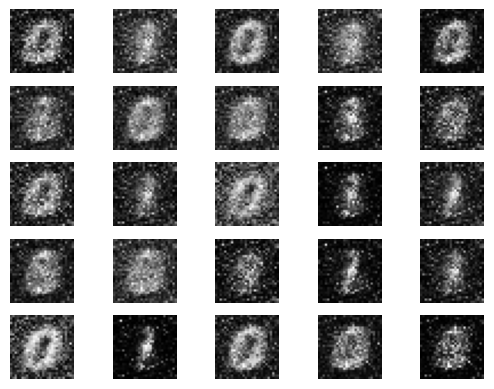

[26/400][0/16] 	Loss_D: 0.6694	Loss_G: -0.3290	D(x): 0.6101	D(G(z)): 0.1128
[27/400][0/16] 	Loss_D: 0.8549	Loss_G: -0.0591	D(x): 0.9341	D(G(z)): 0.5166
[28/400][0/16] 	Loss_D: 0.7519	Loss_G: -0.2422	D(x): 0.8047	D(G(z)): 0.3856
[29/400][0/16] 	Loss_D: 1.2349	Loss_G: -0.5663	D(x): 0.4612	D(G(z)): 0.2397
[30/400][0/16] 	Loss_D: 1.1164	Loss_G: -0.7139	D(x): 0.4307	D(G(z)): 0.1520
[31/400][0/16] 	Loss_D: 0.8958	Loss_G: -0.3128	D(x): 0.6633	D(G(z)): 0.3516
[32/400][0/16] 	Loss_D: 0.6060	Loss_G: -0.1909	D(x): 0.7740	D(G(z)): 0.2698
[33/400][0/16] 	Loss_D: 1.0845	Loss_G: -0.2096	D(x): 0.7635	D(G(z)): 0.5302
[34/400][0/16] 	Loss_D: 0.4870	Loss_G: -0.3107	D(x): 0.7235	D(G(z)): 0.1229
[35/400][0/16] 	Loss_D: 0.7613	Loss_G: -0.4706	D(x): 0.5968	D(G(z)): 0.1815
[36/400][0/16] 	Loss_D: 0.9503	Loss_G: -0.0376	D(x): 0.9359	D(G(z)): 0.5547
[37/400][0/16] 	Loss_D: 0.8072	Loss_G: -0.1125	D(x): 0.8830	D(G(z)): 0.4747
[38/400][0/16] 	Loss_D: 0.8298	Loss_G: -0.5159	D(x): 0.6534	D(G(z)): 0.2416
[39/400][0/1

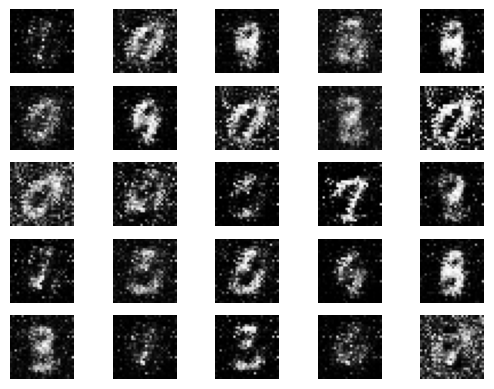

[51/400][0/16] 	Loss_D: 1.2792	Loss_G: -0.2373	D(x): 0.8256	D(G(z)): 0.6366
[52/400][0/16] 	Loss_D: 0.7764	Loss_G: -0.1979	D(x): 0.8550	D(G(z)): 0.4345
[53/400][0/16] 	Loss_D: 0.6830	Loss_G: -0.2053	D(x): 0.7915	D(G(z)): 0.3242
[54/400][0/16] 	Loss_D: 0.8501	Loss_G: -0.2392	D(x): 0.7468	D(G(z)): 0.4089
[55/400][0/16] 	Loss_D: 0.8513	Loss_G: -0.4653	D(x): 0.5420	D(G(z)): 0.1040
[56/400][0/16] 	Loss_D: 1.3801	Loss_G: -0.1080	D(x): 0.8763	D(G(z)): 0.6877
[57/400][0/16] 	Loss_D: 0.8297	Loss_G: -0.0688	D(x): 0.8662	D(G(z)): 0.4615
[58/400][0/16] 	Loss_D: 0.7617	Loss_G: -0.2079	D(x): 0.7962	D(G(z)): 0.3783
[59/400][0/16] 	Loss_D: 0.8537	Loss_G: -0.6108	D(x): 0.5308	D(G(z)): 0.1078
[60/400][0/16] 	Loss_D: 0.8178	Loss_G: -0.1170	D(x): 0.8607	D(G(z)): 0.4733
[61/400][0/16] 	Loss_D: 0.9570	Loss_G: -0.6240	D(x): 0.5217	D(G(z)): 0.1562
[62/400][0/16] 	Loss_D: 0.7510	Loss_G: -0.0836	D(x): 0.9215	D(G(z)): 0.4709
[63/400][0/16] 	Loss_D: 0.9663	Loss_G: -0.7165	D(x): 0.5827	D(G(z)): 0.2481
[64/400][0/1

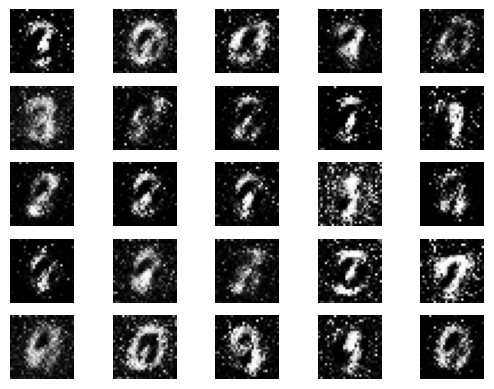

[76/400][0/16] 	Loss_D: 0.4195	Loss_G: -0.2061	D(x): 0.8021	D(G(z)): 0.1591
[77/400][0/16] 	Loss_D: 1.3834	Loss_G: -0.7655	D(x): 0.4047	D(G(z)): 0.2186
[78/400][0/16] 	Loss_D: 0.5830	Loss_G: -0.3218	D(x): 0.6707	D(G(z)): 0.1083
[79/400][0/16] 	Loss_D: 1.2227	Loss_G: -1.1954	D(x): 0.4113	D(G(z)): 0.0606
[80/400][0/16] 	Loss_D: 0.6485	Loss_G: -0.2593	D(x): 0.7324	D(G(z)): 0.2341
[81/400][0/16] 	Loss_D: 0.9054	Loss_G: -0.0456	D(x): 0.8938	D(G(z)): 0.5176
[82/400][0/16] 	Loss_D: 1.0060	Loss_G: -0.0961	D(x): 0.7803	D(G(z)): 0.5056
[83/400][0/16] 	Loss_D: 0.5312	Loss_G: -0.1696	D(x): 0.7849	D(G(z)): 0.2146
[84/400][0/16] 	Loss_D: 0.8802	Loss_G: -0.5922	D(x): 0.5483	D(G(z)): 0.1515
[85/400][0/16] 	Loss_D: 0.8008	Loss_G: -0.1059	D(x): 0.8549	D(G(z)): 0.4287
[86/400][0/16] 	Loss_D: 0.8807	Loss_G: -0.0503	D(x): 0.8936	D(G(z)): 0.5034
[87/400][0/16] 	Loss_D: 0.5244	Loss_G: -0.2271	D(x): 0.7796	D(G(z)): 0.2071
[88/400][0/16] 	Loss_D: 1.0576	Loss_G: -0.1495	D(x): 0.8259	D(G(z)): 0.5376
[89/400][0/1

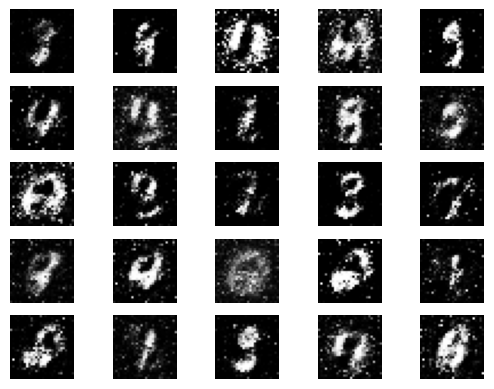

[101/400][0/16] 	Loss_D: 0.5360	Loss_G: -0.1501	D(x): 0.8643	D(G(z)): 0.2860
[102/400][0/16] 	Loss_D: 0.4555	Loss_G: -0.0830	D(x): 0.8781	D(G(z)): 0.2586
[103/400][0/16] 	Loss_D: 0.4779	Loss_G: -0.0956	D(x): 0.8276	D(G(z)): 0.2163
[104/400][0/16] 	Loss_D: 0.4440	Loss_G: -0.1894	D(x): 0.7290	D(G(z)): 0.0840
[105/400][0/16] 	Loss_D: 0.3913	Loss_G: -0.1878	D(x): 0.8175	D(G(z)): 0.1469
[106/400][0/16] 	Loss_D: 0.6133	Loss_G: -0.2583	D(x): 0.6734	D(G(z)): 0.0873
[107/400][0/16] 	Loss_D: 0.9311	Loss_G: -0.6052	D(x): 0.5162	D(G(z)): 0.0296
[108/400][0/16] 	Loss_D: 0.8734	Loss_G: -0.5010	D(x): 0.5469	D(G(z)): 0.0382
[109/400][0/16] 	Loss_D: 0.9035	Loss_G: -0.0401	D(x): 0.9504	D(G(z)): 0.5202
[110/400][0/16] 	Loss_D: 0.3641	Loss_G: -0.0431	D(x): 0.9422	D(G(z)): 0.2440
[111/400][0/16] 	Loss_D: 0.7046	Loss_G: -0.1633	D(x): 0.8772	D(G(z)): 0.3760
[112/400][0/16] 	Loss_D: 0.3722	Loss_G: -0.0942	D(x): 0.8984	D(G(z)): 0.2115
[113/400][0/16] 	Loss_D: 0.3982	Loss_G: -0.0947	D(x): 0.8889	D(G(z)): 0.2043

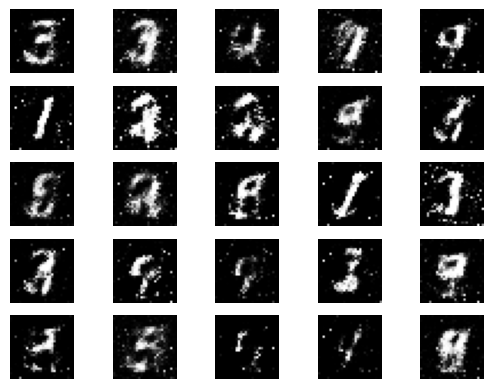

[126/400][0/16] 	Loss_D: 0.3232	Loss_G: -0.1430	D(x): 0.8201	D(G(z)): 0.0603
[127/400][0/16] 	Loss_D: 0.4215	Loss_G: -0.0686	D(x): 0.8822	D(G(z)): 0.2172
[128/400][0/16] 	Loss_D: 0.4674	Loss_G: -0.0629	D(x): 0.7671	D(G(z)): 0.0378
[129/400][0/16] 	Loss_D: 0.6079	Loss_G: -0.0416	D(x): 0.9564	D(G(z)): 0.3715
[130/400][0/16] 	Loss_D: 1.7181	Loss_G: -0.0168	D(x): 0.9813	D(G(z)): 0.7571
[131/400][0/16] 	Loss_D: 1.1608	Loss_G: -0.0864	D(x): 0.9365	D(G(z)): 0.5958
[132/400][0/16] 	Loss_D: 0.3223	Loss_G: -0.0874	D(x): 0.8750	D(G(z)): 0.1433
[133/400][0/16] 	Loss_D: 0.4648	Loss_G: -0.0326	D(x): 0.9140	D(G(z)): 0.2750
[134/400][0/16] 	Loss_D: 0.5752	Loss_G: -0.2488	D(x): 0.7368	D(G(z)): 0.1711
[135/400][0/16] 	Loss_D: 0.4553	Loss_G: -0.1747	D(x): 0.7850	D(G(z)): 0.1309
[136/400][0/16] 	Loss_D: 0.6871	Loss_G: -0.1109	D(x): 0.8409	D(G(z)): 0.3341
[137/400][0/16] 	Loss_D: 0.4695	Loss_G: -0.0767	D(x): 0.8660	D(G(z)): 0.2451
[138/400][0/16] 	Loss_D: 0.4006	Loss_G: -0.2450	D(x): 0.7906	D(G(z)): 0.0949

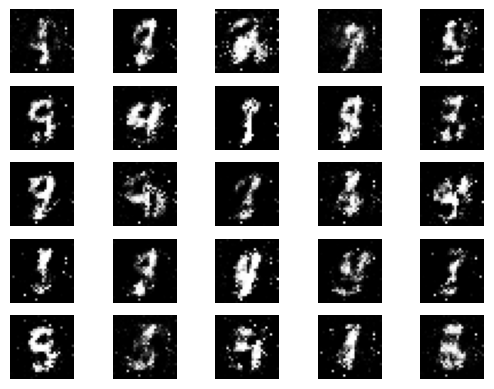

[151/400][0/16] 	Loss_D: 0.3891	Loss_G: -0.2549	D(x): 0.8075	D(G(z)): 0.0680
[152/400][0/16] 	Loss_D: 0.8275	Loss_G: -0.0269	D(x): 0.9488	D(G(z)): 0.4754
[153/400][0/16] 	Loss_D: 0.2790	Loss_G: -0.0699	D(x): 0.9041	D(G(z)): 0.1354
[154/400][0/16] 	Loss_D: 0.7108	Loss_G: -0.0402	D(x): 0.9397	D(G(z)): 0.3910
[155/400][0/16] 	Loss_D: 0.3326	Loss_G: -0.1545	D(x): 0.8390	D(G(z)): 0.0868
[156/400][0/16] 	Loss_D: 0.4624	Loss_G: -0.1958	D(x): 0.7488	D(G(z)): 0.0675
[157/400][0/16] 	Loss_D: 0.3587	Loss_G: -0.0499	D(x): 0.9172	D(G(z)): 0.2109
[158/400][0/16] 	Loss_D: 0.3242	Loss_G: -0.0964	D(x): 0.9253	D(G(z)): 0.1980
[159/400][0/16] 	Loss_D: 0.2283	Loss_G: -0.1201	D(x): 0.8626	D(G(z)): 0.0509
[160/400][0/16] 	Loss_D: 1.2735	Loss_G: -0.2414	D(x): 0.5026	D(G(z)): 0.0050
[161/400][0/16] 	Loss_D: 0.4606	Loss_G: -0.0582	D(x): 0.9031	D(G(z)): 0.2552
[162/400][0/16] 	Loss_D: 0.2729	Loss_G: -0.0700	D(x): 0.8802	D(G(z)): 0.0973
[163/400][0/16] 	Loss_D: 0.2332	Loss_G: -0.0459	D(x): 0.9218	D(G(z)): 0.1211

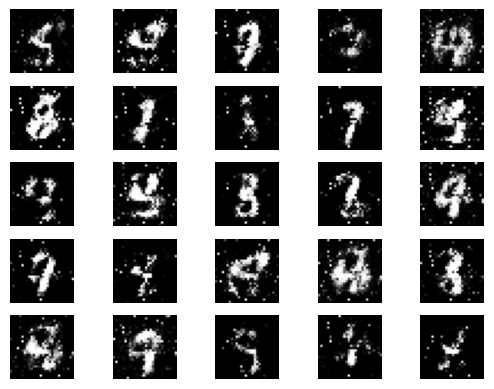

[176/400][0/16] 	Loss_D: 0.2928	Loss_G: -0.0504	D(x): 0.9476	D(G(z)): 0.1924
[177/400][0/16] 	Loss_D: 0.9523	Loss_G: -0.7921	D(x): 0.5917	D(G(z)): 0.0166
[178/400][0/16] 	Loss_D: 0.5496	Loss_G: -0.4469	D(x): 0.7190	D(G(z)): 0.0563
[179/400][0/16] 	Loss_D: 0.4057	Loss_G: -0.1028	D(x): 0.8177	D(G(z)): 0.1477
[180/400][0/16] 	Loss_D: 0.7185	Loss_G: -0.5784	D(x): 0.6106	D(G(z)): 0.0605
[181/400][0/16] 	Loss_D: 0.6091	Loss_G: -0.2525	D(x): 0.6895	D(G(z)): 0.0576
[182/400][0/16] 	Loss_D: 0.9972	Loss_G: -0.0116	D(x): 0.9573	D(G(z)): 0.5283
[183/400][0/16] 	Loss_D: 0.5446	Loss_G: -0.2057	D(x): 0.7146	D(G(z)): 0.0489
[184/400][0/16] 	Loss_D: 0.5292	Loss_G: -0.2126	D(x): 0.8044	D(G(z)): 0.1748
[185/400][0/16] 	Loss_D: 0.6375	Loss_G: -0.0328	D(x): 0.9617	D(G(z)): 0.3979
[186/400][0/16] 	Loss_D: 0.4240	Loss_G: -0.1625	D(x): 0.8124	D(G(z)): 0.1250
[187/400][0/16] 	Loss_D: 0.5644	Loss_G: -0.3837	D(x): 0.7114	D(G(z)): 0.1119
[188/400][0/16] 	Loss_D: 0.4504	Loss_G: -0.1011	D(x): 0.8669	D(G(z)): 0.2373

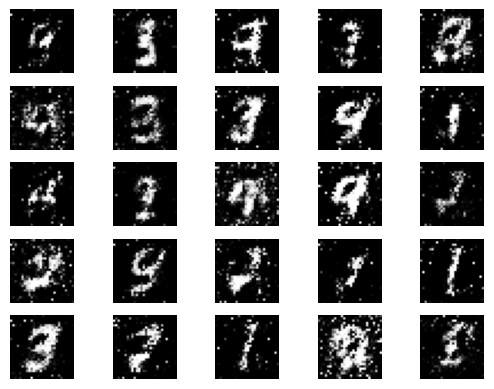

[201/400][0/16] 	Loss_D: 0.5078	Loss_G: -0.0365	D(x): 0.9388	D(G(z)): 0.3054
[202/400][0/16] 	Loss_D: 0.6940	Loss_G: -0.0315	D(x): 0.9546	D(G(z)): 0.4082
[203/400][0/16] 	Loss_D: 1.2148	Loss_G: -0.0018	D(x): 0.9711	D(G(z)): 0.6151
[204/400][0/16] 	Loss_D: 0.3721	Loss_G: -0.0747	D(x): 0.8166	D(G(z)): 0.1029
[205/400][0/16] 	Loss_D: 0.3784	Loss_G: -0.0850	D(x): 0.8804	D(G(z)): 0.1700
[206/400][0/16] 	Loss_D: 0.4988	Loss_G: -0.0143	D(x): 0.9313	D(G(z)): 0.3034
[207/400][0/16] 	Loss_D: 0.2141	Loss_G: -0.0704	D(x): 0.8985	D(G(z)): 0.0823
[208/400][0/16] 	Loss_D: 0.2742	Loss_G: -0.0477	D(x): 0.9220	D(G(z)): 0.1530
[209/400][0/16] 	Loss_D: 0.5826	Loss_G: -0.2424	D(x): 0.7438	D(G(z)): 0.1283
[210/400][0/16] 	Loss_D: 0.8496	Loss_G: -0.0260	D(x): 0.9023	D(G(z)): 0.4633
[211/400][0/16] 	Loss_D: 0.3455	Loss_G: -0.0314	D(x): 0.9544	D(G(z)): 0.2310
[212/400][0/16] 	Loss_D: 0.8222	Loss_G: -0.0250	D(x): 0.9570	D(G(z)): 0.4479
[213/400][0/16] 	Loss_D: 0.5416	Loss_G: -0.0070	D(x): 0.9677	D(G(z)): 0.3598

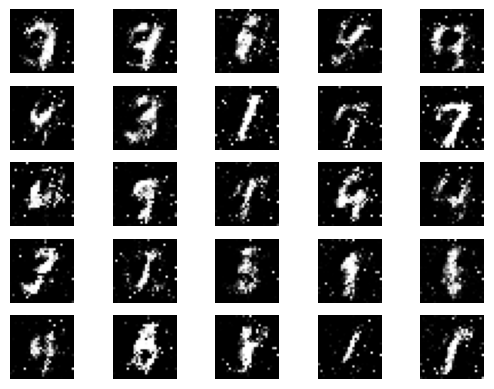

[226/400][0/16] 	Loss_D: 0.4333	Loss_G: -0.2636	D(x): 0.7756	D(G(z)): 0.0911
[227/400][0/16] 	Loss_D: 0.2997	Loss_G: -0.1490	D(x): 0.8345	D(G(z)): 0.0729
[228/400][0/16] 	Loss_D: 0.5775	Loss_G: -0.0106	D(x): 0.9302	D(G(z)): 0.3235
[229/400][0/16] 	Loss_D: 1.5925	Loss_G: -0.1032	D(x): 0.9416	D(G(z)): 0.6509
[230/400][0/16] 	Loss_D: 0.5956	Loss_G: -0.0647	D(x): 0.9494	D(G(z)): 0.3684
[231/400][0/16] 	Loss_D: 0.7268	Loss_G: -0.0169	D(x): 0.9600	D(G(z)): 0.4162
[232/400][0/16] 	Loss_D: 1.4094	Loss_G: -0.0065	D(x): 0.9655	D(G(z)): 0.6936
[233/400][0/16] 	Loss_D: 0.5863	Loss_G: -0.1709	D(x): 0.7876	D(G(z)): 0.2237
[234/400][0/16] 	Loss_D: 1.1887	Loss_G: -0.0256	D(x): 0.9520	D(G(z)): 0.6145
[235/400][0/16] 	Loss_D: 0.7708	Loss_G: -0.0237	D(x): 0.9411	D(G(z)): 0.4537
[236/400][0/16] 	Loss_D: 0.5676	Loss_G: -0.4733	D(x): 0.6735	D(G(z)): 0.0722
[237/400][0/16] 	Loss_D: 0.4011	Loss_G: -0.0720	D(x): 0.9379	D(G(z)): 0.2412
[238/400][0/16] 	Loss_D: 0.4089	Loss_G: -0.2641	D(x): 0.7793	D(G(z)): 0.0953

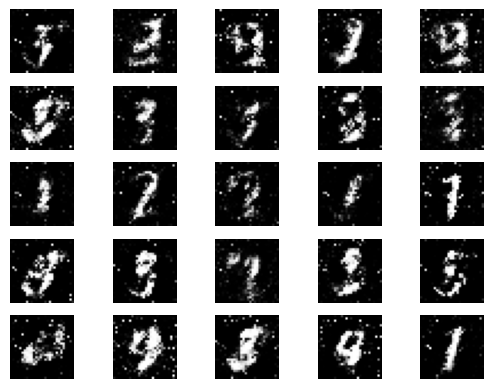

[251/400][0/16] 	Loss_D: 0.9688	Loss_G: -0.0287	D(x): 0.9550	D(G(z)): 0.4988
[252/400][0/16] 	Loss_D: 0.3610	Loss_G: -0.0595	D(x): 0.9197	D(G(z)): 0.2115
[253/400][0/16] 	Loss_D: 2.0639	Loss_G: -0.0034	D(x): 0.9864	D(G(z)): 0.8319
[254/400][0/16] 	Loss_D: 0.4772	Loss_G: -0.2126	D(x): 0.7458	D(G(z)): 0.0843
[255/400][0/16] 	Loss_D: 0.3251	Loss_G: -0.1677	D(x): 0.8386	D(G(z)): 0.0885
[256/400][0/16] 	Loss_D: 0.3625	Loss_G: -0.1092	D(x): 0.8724	D(G(z)): 0.1597
[257/400][0/16] 	Loss_D: 0.3697	Loss_G: -0.1908	D(x): 0.7803	D(G(z)): 0.0580
[258/400][0/16] 	Loss_D: 0.9389	Loss_G: -0.0026	D(x): 0.9737	D(G(z)): 0.5196
[259/400][0/16] 	Loss_D: 0.4205	Loss_G: -0.0939	D(x): 0.9099	D(G(z)): 0.2527
[260/400][0/16] 	Loss_D: 0.4038	Loss_G: -0.1119	D(x): 0.9052	D(G(z)): 0.1879
[261/400][0/16] 	Loss_D: 1.2501	Loss_G: -0.0084	D(x): 0.9835	D(G(z)): 0.6193
[262/400][0/16] 	Loss_D: 0.6896	Loss_G: -0.7379	D(x): 0.6303	D(G(z)): 0.0606
[263/400][0/16] 	Loss_D: 0.3500	Loss_G: -0.1663	D(x): 0.8452	D(G(z)): 0.1031

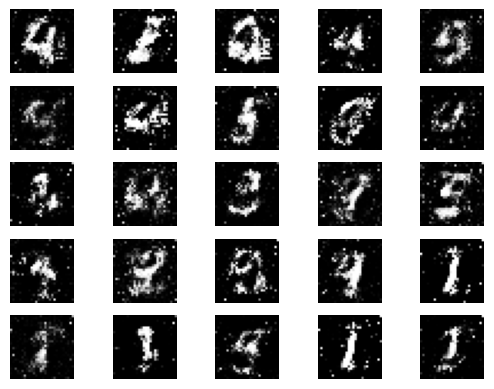

[276/400][0/16] 	Loss_D: 0.4313	Loss_G: -0.2573	D(x): 0.7803	D(G(z)): 0.1000
[277/400][0/16] 	Loss_D: 0.3910	Loss_G: -0.0280	D(x): 0.9268	D(G(z)): 0.2425
[278/400][0/16] 	Loss_D: 0.4732	Loss_G: -0.2806	D(x): 0.7670	D(G(z)): 0.1012
[279/400][0/16] 	Loss_D: 0.6562	Loss_G: -0.2691	D(x): 0.7121	D(G(z)): 0.1233
[280/400][0/16] 	Loss_D: 0.4650	Loss_G: -0.2715	D(x): 0.7559	D(G(z)): 0.1058
[281/400][0/16] 	Loss_D: 0.8244	Loss_G: -0.0640	D(x): 0.9349	D(G(z)): 0.4469
[282/400][0/16] 	Loss_D: 0.5191	Loss_G: -0.1187	D(x): 0.8481	D(G(z)): 0.2364
[283/400][0/16] 	Loss_D: 0.4961	Loss_G: -0.0633	D(x): 0.8919	D(G(z)): 0.2755
[284/400][0/16] 	Loss_D: 0.4649	Loss_G: -0.1522	D(x): 0.7972	D(G(z)): 0.1463
[285/400][0/16] 	Loss_D: 0.5218	Loss_G: -0.2815	D(x): 0.7484	D(G(z)): 0.1065
[286/400][0/16] 	Loss_D: 1.3753	Loss_G: -0.8147	D(x): 0.4632	D(G(z)): 0.0070
[287/400][0/16] 	Loss_D: 0.6674	Loss_G: -0.0225	D(x): 0.9337	D(G(z)): 0.3942
[288/400][0/16] 	Loss_D: 0.4723	Loss_G: -0.0751	D(x): 0.8925	D(G(z)): 0.2566

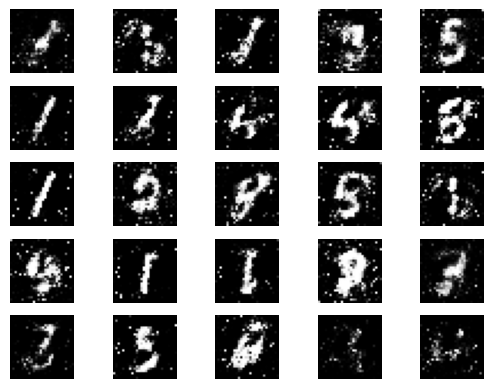

[301/400][0/16] 	Loss_D: 0.4006	Loss_G: -0.1037	D(x): 0.9101	D(G(z)): 0.2116
[302/400][0/16] 	Loss_D: 0.3081	Loss_G: -0.0703	D(x): 0.9359	D(G(z)): 0.1769
[303/400][0/16] 	Loss_D: 0.5085	Loss_G: -0.0380	D(x): 0.9289	D(G(z)): 0.3030
[304/400][0/16] 	Loss_D: 0.5398	Loss_G: -0.1620	D(x): 0.7668	D(G(z)): 0.1145
[305/400][0/16] 	Loss_D: 0.5447	Loss_G: -0.0690	D(x): 0.9310	D(G(z)): 0.3202
[306/400][0/16] 	Loss_D: 0.3653	Loss_G: -0.1988	D(x): 0.8274	D(G(z)): 0.0945
[307/400][0/16] 	Loss_D: 0.3200	Loss_G: -0.1405	D(x): 0.8440	D(G(z)): 0.1040
[308/400][0/16] 	Loss_D: 0.4266	Loss_G: -0.1145	D(x): 0.8376	D(G(z)): 0.1650
[309/400][0/16] 	Loss_D: 0.4456	Loss_G: -0.3166	D(x): 0.7597	D(G(z)): 0.0806
[310/400][0/16] 	Loss_D: 0.4683	Loss_G: -0.0128	D(x): 0.9563	D(G(z)): 0.2952
[311/400][0/16] 	Loss_D: 0.5778	Loss_G: -0.3713	D(x): 0.7058	D(G(z)): 0.0963
[312/400][0/16] 	Loss_D: 0.5448	Loss_G: -0.5623	D(x): 0.6855	D(G(z)): 0.0770
[313/400][0/16] 	Loss_D: 0.5594	Loss_G: -0.1338	D(x): 0.9243	D(G(z)): 0.3061

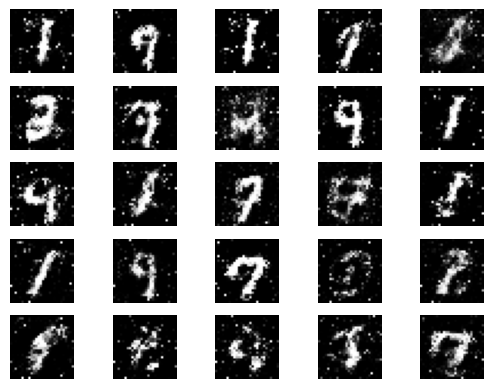

[326/400][0/16] 	Loss_D: 0.4495	Loss_G: -0.1220	D(x): 0.7794	D(G(z)): 0.1108
[327/400][0/16] 	Loss_D: 0.6124	Loss_G: -0.0343	D(x): 0.9451	D(G(z)): 0.3679
[328/400][0/16] 	Loss_D: 0.4210	Loss_G: -0.0577	D(x): 0.8857	D(G(z)): 0.2304
[329/400][0/16] 	Loss_D: 0.6095	Loss_G: -0.0360	D(x): 0.9161	D(G(z)): 0.3498
[330/400][0/16] 	Loss_D: 0.9875	Loss_G: -0.0251	D(x): 0.9509	D(G(z)): 0.5198
[331/400][0/16] 	Loss_D: 0.6737	Loss_G: -0.1926	D(x): 0.6846	D(G(z)): 0.0558
[332/400][0/16] 	Loss_D: 0.3996	Loss_G: -0.0893	D(x): 0.8549	D(G(z)): 0.1761
[333/400][0/16] 	Loss_D: 0.6499	Loss_G: -0.2033	D(x): 0.6853	D(G(z)): 0.0400
[334/400][0/16] 	Loss_D: 0.5349	Loss_G: -0.2408	D(x): 0.7802	D(G(z)): 0.1511
[335/400][0/16] 	Loss_D: 0.6901	Loss_G: -0.0131	D(x): 0.9277	D(G(z)): 0.4006
[336/400][0/16] 	Loss_D: 0.3789	Loss_G: -0.1241	D(x): 0.8560	D(G(z)): 0.1619
[337/400][0/16] 	Loss_D: 1.0321	Loss_G: -0.0088	D(x): 0.9638	D(G(z)): 0.5544
[338/400][0/16] 	Loss_D: 1.1133	Loss_G: -0.0229	D(x): 0.9454	D(G(z)): 0.5780

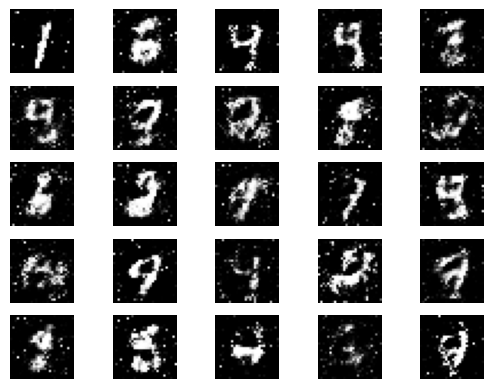

[351/400][0/16] 	Loss_D: 0.4907	Loss_G: -0.0393	D(x): 0.9143	D(G(z)): 0.2927
[352/400][0/16] 	Loss_D: 0.4223	Loss_G: -0.0770	D(x): 0.8543	D(G(z)): 0.1860
[353/400][0/16] 	Loss_D: 0.7365	Loss_G: -0.0384	D(x): 0.9188	D(G(z)): 0.4124
[354/400][0/16] 	Loss_D: 0.4149	Loss_G: -0.1868	D(x): 0.8422	D(G(z)): 0.1633
[355/400][0/16] 	Loss_D: 0.6063	Loss_G: -0.6756	D(x): 0.6780	D(G(z)): 0.0496
[356/400][0/16] 	Loss_D: 0.4083	Loss_G: -0.2492	D(x): 0.8147	D(G(z)): 0.1348
[357/400][0/16] 	Loss_D: 0.3538	Loss_G: -0.0560	D(x): 0.9042	D(G(z)): 0.1988
[358/400][0/16] 	Loss_D: 0.3718	Loss_G: -0.0685	D(x): 0.9123	D(G(z)): 0.2078
[359/400][0/16] 	Loss_D: 0.6803	Loss_G: -0.5232	D(x): 0.6597	D(G(z)): 0.1032
[360/400][0/16] 	Loss_D: 0.3760	Loss_G: -0.2333	D(x): 0.7668	D(G(z)): 0.0421
[361/400][0/16] 	Loss_D: 0.5250	Loss_G: -0.3844	D(x): 0.7048	D(G(z)): 0.0443
[362/400][0/16] 	Loss_D: 0.4715	Loss_G: -0.0473	D(x): 0.9120	D(G(z)): 0.2545
[363/400][0/16] 	Loss_D: 0.4595	Loss_G: -0.2732	D(x): 0.7277	D(G(z)): 0.0594

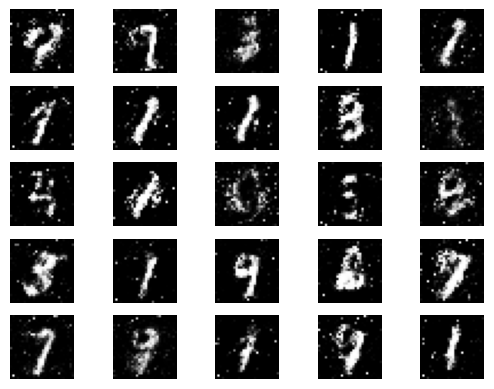

[376/400][0/16] 	Loss_D: 0.4699	Loss_G: -0.0490	D(x): 0.8777	D(G(z)): 0.2433
[377/400][0/16] 	Loss_D: 0.4310	Loss_G: -0.1450	D(x): 0.8224	D(G(z)): 0.1517
[378/400][0/16] 	Loss_D: 0.7223	Loss_G: -0.0800	D(x): 0.9421	D(G(z)): 0.4219
[379/400][0/16] 	Loss_D: 0.4891	Loss_G: -0.2052	D(x): 0.7878	D(G(z)): 0.1594
[380/400][0/16] 	Loss_D: 0.4016	Loss_G: -0.0982	D(x): 0.8656	D(G(z)): 0.1896
[381/400][0/16] 	Loss_D: 0.7845	Loss_G: -0.2490	D(x): 0.6330	D(G(z)): 0.0373
[382/400][0/16] 	Loss_D: 1.0486	Loss_G: -0.0480	D(x): 0.9656	D(G(z)): 0.5737
[383/400][0/16] 	Loss_D: 0.7071	Loss_G: -0.5120	D(x): 0.6807	D(G(z)): 0.1204
[384/400][0/16] 	Loss_D: 0.5424	Loss_G: -0.5003	D(x): 0.6950	D(G(z)): 0.0834
[385/400][0/16] 	Loss_D: 0.4833	Loss_G: -0.1753	D(x): 0.8283	D(G(z)): 0.1980
[386/400][0/16] 	Loss_D: 0.4745	Loss_G: -0.3078	D(x): 0.7743	D(G(z)): 0.0957
[387/400][0/16] 	Loss_D: 0.9352	Loss_G: -0.0149	D(x): 0.9474	D(G(z)): 0.5094
[388/400][0/16] 	Loss_D: 0.6597	Loss_G: -0.0389	D(x): 0.9191	D(G(z)): 0.3726

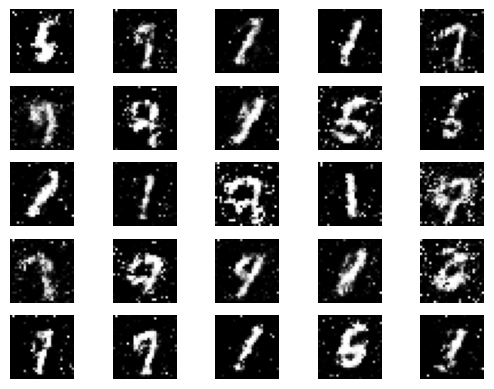

In [ ]:

# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []


sample_interval=25

print("Starting Training")
# For each epoch
for epoch in range(n_epochs):
  # For each batch in the dataloader
  for i, data in enumerate(mnist_train_loader, 0):
    for iter_inner in range(0,n_iters_inner):

      ############################
      ### Train discriminator
      ############################
      ## Train with true data batch
      disc_model.zero_grad()
      # create true data and labels
      true_imgs = data[0].to(device)
      true_labels = torch.ones(true_imgs.size(0), device=device) # FILL IN HERE. CAREFUL, WE WANT A 1-DIMENSIONAL TENSOR OF LABELS (DUE TO THE "VIEW" IN NEXT LINE)
      # put true data through discriminator
      d_output_true = disc_model(true_imgs).view(-1) # FILL IN HERE
      # bce loss on true data
      d_loss_true = bce_criterion(d_output_true, true_labels) # FILL IN HERE
      # backpropagation for discriminator, true loss
      d_loss_true.backward()
      disc_true_value = d_output_true.mean().item()

      ## Train with fake data batch
      # create fake data and labels
      # generate batch of random latent vectors
      z_latent_noise = torch.randn(true_imgs.shape[0], z_dim, device=device) # FILL IN HERE
      # Generate batch of fake images
      fake_imgs = gen_model(z_latent_noise)  # FILL IN HERE
      fake_labels = torch.zeros(fake_imgs.shape[0], device=device) # FILL IN HERE
      # put fake data through discriminator
      disc_output_fake = disc_model(fake_imgs.detach()).view(-1)
      # bce loss on fake data
      disc_loss_fake = bce_criterion(disc_output_fake, fake_labels)  # FILL IN HERE
      # backpropagation for discriminator, fake loss
      disc_loss_fake.backward()
      disc_fake_value = disc_output_fake.mean().item()
      # Update discriminator
      optimizer_disc.step()

      d_loss_total = d_loss_true+disc_loss_fake

    ############################
    ### Train generator
    ############################
    gen_model.zero_grad()
    # We have updated the discriminator, so we need to update the output of the discriminator
    disc_gen_output_fake = disc_model(fake_imgs).view(-1) # FILL IN HERE
    # Generator loss, using the custom loss
    g_loss = loss_fn_gen(disc_gen_output_fake) # FILL IN HERE
    # backpropagation for generator
    g_loss.backward()
    #D_G_z2 = output.mean().item()
    # Update generator
    optimizer_gen.step()

    # Output training stats
    if i % 200 == 0:
      print('[%d/%d][%d/%d] \tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f'
      % (epoch, n_epochs, i, len(mnist_train_loader),d_loss_total.item(), g_loss.item(), disc_true_value, disc_fake_value ))

    # Save Losses for plotting later
    G_losses.append(g_loss.item())
    D_losses.append(d_loss_total.item())


  if(epoch % sample_interval == 0):
    sample_images(gen_model,z_dim, rand_seed=30)

# end samples
sample_images(gen_model,z_dim, rand_seed=30)


Hopefully, you have managed to get the GAN working. Yoohoo !! You should notice that the results are much less smooth than those of the variational autoencoder. This is normal, in general a GAN produces sharper results, but is quite difficult to get working well. You can try and modify the latent space to see whether this improves the results.

## Navigating in the latent space

One of the main interests in the latent space is to be able to __navigate__ in it. For instance, one operation which is very common is to take two points $z_0$ and $z_1$ and to interpolate between the two. The images resulting from the generation of the interpolated points should ideally be a mix between the two initial points.

The simplest method of interpolation is simply linear interpolation along the line connecting the two points. Obviously, this supposes that the latent space is linear in some sense, which may not be true, but we are going to take this approach here.

First, find two inital points $z_0$ and $z_1$ which you feel represent two different digits well, and display their resulting generated images.  

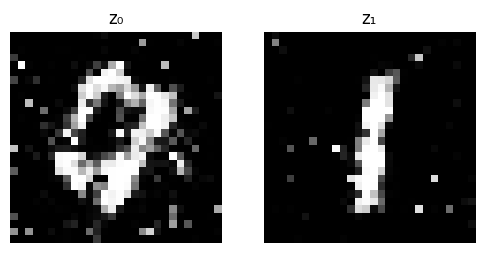

In [ ]:
# first image
random_seed = 110 # change this seed to find the best image
torch.manual_seed(random_seed)
z_0 = torch.randn(1, z_dim, device=device) # FILL IN HERE
x_0 = gen_model(z_0) # FILL IN HERE

random_seed = 64 # change this seed to find the best image
torch.manual_seed(random_seed)
z_1 = torch.randn(1, z_dim, device=device) # FILL IN HERE
x_1 = gen_model(z_1) # FILL IN HERE

# display images
# FILL IN HERE
x_0_img = x_0.detach().cpu().squeeze().numpy()
x_1_img = x_1.detach().cpu().squeeze().numpy()

# Rescale [-1,1] → [0,1]
x_0_img = 0.5 * x_0_img + 0.5
x_1_img = 0.5 * x_1_img + 0.5

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(x_0_img, cmap='gray')
plt.title("z₀")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(x_1_img, cmap='gray')
plt.title("z₁")
plt.axis("off")

plt.show()


Now, carry out the interpolation between these two points. You should __include__ the starting and ending codes $z_0$ and $z_1$. Display the results.

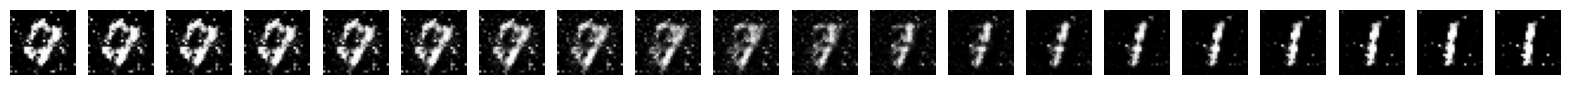

In [ ]:
n_interpolation = 20

# FILL IN HERE
n_interpolation = 20

# create interpolation coefficients between 0 and 1
alphas = torch.linspace(0, 1, n_interpolation, device=device)

# list to store generated images
generated_images = []

for alpha in alphas:
    # linear interpolation
    z_interp = (1 - alpha) * z_0 + alpha * z_1

    # generate image
    x_interp = gen_model(z_interp)

    generated_images.append(x_interp.detach().cpu())

# concatenate all images
generated_images = torch.cat(generated_images, dim=0)

# rescale from [-1,1] → [0,1]
generated_images = 0.5 * generated_images + 0.5

# plot
plt.figure(figsize=(20, 2))

for i in range(n_interpolation):
    plt.subplot(1, n_interpolation, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis("off")

plt.show()


What do you think of the quality of the output images ?

__Answer__

### Evaluation

Now, we are going to evaluate this navigation. We will investigate the following property:

- We are going to see whether by navigating between two points, the model produces images which are categorised in either of the classes (beginning class or end class), or if it traverses a region which is categorised in another class;

For this, we will first need a classification network. Use the following architecture :

- conv2d, filter size  3×3 , 32 filters, stride=(2,2), padding="SAME"
- ReLU
- conv2d, filter size  3×3 , 32 filters, stride=(2,2), padding="SAME"
- ReLU
- MaxPool2D, stride=(2,2)
- Flatten
- Dense layer

We also define a function ```get_accuracy``` to calculate the accuracy of our network.

In [ ]:
# define mnist classifier model, loss function, optimiser and the function 'get_accuracy' (already done)

# BEGIN FILL IN HERE
# BEGIN FILL IN HERE

class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 3 * 3, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


classifier = MNISTClassifier().to(device)

criterion_cls = nn.CrossEntropyLoss()

optimizer_cls = torch.optim.Adam(classifier.parameters(), lr=1e-3)

# END FILL IN HERE

# END FILL IN HERE

def get_accuracy(x_pred,x_label):
  acc = torch.sum(x_pred == x_label)/(x_pred.shape[0])
  return acc

In [ ]:
# train the classifier
n_epochs_cls = 5

for epoch in range(n_epochs_cls):

    classifier.train()
    train_loss = 0
    train_acc = 0

    for imgs, labels in mnist_train_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer_cls.zero_grad()

        outputs = classifier(imgs)

        loss = criterion_cls(outputs, labels)

        loss.backward()
        optimizer_cls.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_acc += get_accuracy(preds, labels).item()


    train_loss /= len(mnist_train_loader)
    train_acc /= len(mnist_train_loader)


    # ---- Evaluation ----
    classifier.eval()
    test_acc = 0

    with torch.no_grad():
        for imgs, labels in mnist_test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = classifier(imgs)
            preds = torch.argmax(outputs, dim=1)
            test_acc += get_accuracy(preds, labels).item()

    test_acc /= len(mnist_test_loader)


    print(f"Epoch [{epoch+1}/{n_epochs_cls}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Test Acc: {test_acc:.4f}")


# FILL IN HERE

Epoch [1/5] Train Loss: 2.2501 Train Acc: 0.1994 Test Acc: 0.3457
Epoch [2/5] Train Loss: 2.0142 Train Acc: 0.4908 Test Acc: 0.4629
Epoch [3/5] Train Loss: 1.5498 Train Acc: 0.6277 Test Acc: 0.6992
Epoch [4/5] Train Loss: 1.0348 Train Acc: 0.7600 Test Acc: 0.7773
Epoch [5/5] Train Loss: 0.7039 Train Acc: 0.8385 Test Acc: 0.8184



Now, create a function which returns the classification returned by this network on mnist images. Remember, here we want the argmax, rather than the maximum probability. __Note__: the torch.max function returns a tuple: (max_values, max_indices).

In [ ]:
def predict_mnist_class(imgs_in, classification_model):
    classification_model.eval()

    with torch.no_grad():
        outputs = classification_model(imgs_in)
        output_classes = torch.argmax(outputs, dim=1)

    return output_classes

Carry out and print the classification of your interpolated latent space images. What are your remarks ? Does the latent space navigation traverse regions with classes other than those of $z_0$ and $z_1$ ?

In [ ]:
z_classes = predict_mnist_class(generated_images.to(device), classifier)
print(z_classes.cpu().numpy())

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


__Answer__

# Training on CIFAR (optional)

If you want to try another, more challenging database, use the above code and modify it to carry out the GAN training on the CIFAR10 database. Note, it can take a long time to get good results

First, we download the data.

In [ ]:
# convert input to Pytorch tensors
transform = transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,),(0.5,)),
])

# extract mnist data
cifar_trainset = datasets.CIFAR10(root='./data',train=True,download=True,transform=transform)
print(cifar_trainset)

#create data loader with smaller dataset size
max_cifar_size = 2000
cifar_trainset_reduced = torch.utils.data.random_split(cifar_trainset, [max_cifar_size, len(cifar_trainset)-max_cifar_size])[0]
cifar_train_loader = torch.utils.data.DataLoader(cifar_trainset_reduced, batch_size=64, shuffle=True)

# download test dataset
cifar_testset = datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
cifar_test_loader = torch.utils.data.DataLoader(cifar_testset, batch_size=64, shuffle=True)

n_rows = 32
n_cols = 32
n_channels = 3
n_pixels = n_rows*n_cols

img_shape = (n_rows, n_cols, n_channels)

100%|██████████| 170M/170M [00:04<00:00, 38.8MB/s]


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


Now, we can redefine the hyper-parameters of the model (change if you wish)

In [ ]:
## GAN parameters
z_dim = 10
batch_size = 64
n_epochs = 300
## parameters for training
n_iters_inner=1	#number of internal loops
# Learning rate for optimizers
lr = 0.0002
beta_1 = 0.5

For this case of CIFAR, implement the following architecture :

- Generator :
  - Dense layer to size 1024
  - Leaky ReLU ($\alpha=0.2$)
  - Reshape, to size $4 \times 4 \times64$
  - % size = $4\times4\times64$
  - Conv2d, n_channels=16,kernel size=(3,3), strides=(1,1),padding=(1,1)
  - Upsample(scale_factor=(2,2))
  - %size = $8\times 8\times 16$
  - Leaky ReLU ($\alpha=0.2$)
  - Conv2d, n_channels=16,kernel size=(3,3), strides=(1,1),padding=(1,1)
  - Upsample(scale_factor=(2,2))
  - %size=$16 \times 16 \times 16$
  - Leaky ReLU ($\alpha=0.2$)
  - Conv2d, n_channels=3,kernel size=(3,3), strides=(1,1),padding=(1,1)
  - Upsample(scale_factor=(2,2))
  - %size = $32 \times 32 \times 3$
  - Tanh activation ( you can use ```Activation('tanh')```)

- Discriminator :
  - % input size : $32 \times 32 \times 3$
  - Conv2D, 32 filters, kernel size = (3,3), strides = (1,1),padding = same
  - % size $32 \times 32 \times 32$
  - Leaky ReLU ($\alpha=0.2$)
  - Conv2D, 32 filters, kernel size = (3,3), strides = (2,2),padding = same
  - %size : $16 \times 16 \times 32$
  - Leaky ReLU ($\alpha=0.2$)
  - Conv2D, 64 filters, kernel size = (3,3), strides = (2,2),padding = same
  - % size : $8 \times 8 \times 64$
  - Leaky ReLU ($\alpha=0.2$)
  - Conv2D, 32 filters, kernel size = (3,3), strides = (2,2),padding = same
  - % size : $4 \times 4 \times 32$
  - Leaky ReLU ($\alpha=0.2$)
  - Flatten
  - Dense layer to size 1
  - Sigmoid activation

  Implement this architecture below, and train the GAN.

In [ ]:
class GeneratorCIFAR(nn.Module):
    def __init__(self, z_dim):
        super(GeneratorCIFAR, self).__init__()

        self.fc = nn.Linear(z_dim, 1024)
        self.lrelu = nn.LeakyReLU(0.2)

        self.conv1 = nn.Conv2d(64, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(16, 3, kernel_size=3, stride=1, padding=1)

        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.tanh = nn.Tanh()

    def forward(self, z):
        x = self.fc(z)                  # (B, 1024)
        x = self.lrelu(x)

        x = x.view(-1, 64, 4, 4)        # (B, 64, 4, 4)

        x = self.conv1(x)               # (B, 16, 4, 4)
        x = self.upsample(x)            # (B, 16, 8, 8)
        x = self.lrelu(x)

        x = self.conv2(x)               # (B, 16, 8, 8)
        x = self.upsample(x)            # (B, 16, 16, 16)
        x = self.lrelu(x)

        x = self.conv3(x)               # (B, 3, 16, 16)
        x = self.upsample(x)            # (B, 3, 32, 32)

        x = self.tanh(x)

        return x
class DiscriminatorCIFAR(nn.Module):
    def __init__(self):
        super(DiscriminatorCIFAR, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(64, 32, kernel_size=3, stride=2, padding=1)

        self.lrelu = nn.LeakyReLU(0.2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(32 * 4 * 4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.lrelu(self.conv1(x))   # 32x32x32
        x = self.lrelu(self.conv2(x))   # 16x16x32
        x = self.lrelu(self.conv3(x))   # 8x8x64
        x = self.lrelu(self.conv4(x))   # 4x4x32

        x = self.flatten(x)
        x = self.fc(x)
        x = self.sigmoid(x)

        return x


Now, carry out the training (use code above)

In [ ]:
gen_model = GeneratorCIFAR(z_dim).to(device)
disc_model = DiscriminatorCIFAR().to(device)

bce_criterion = nn.BCELoss()

optimizer_gen = torch.optim.Adam(gen_model.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_disc = torch.optim.Adam(disc_model.parameters(), lr=0.0002, betas=(0.5, 0.999))


Starting Training
[0/300][0/32] 	Loss_D: 1.3854	Loss_G: -0.7143	D(x): 0.5112	D(G(z)): 0.5105


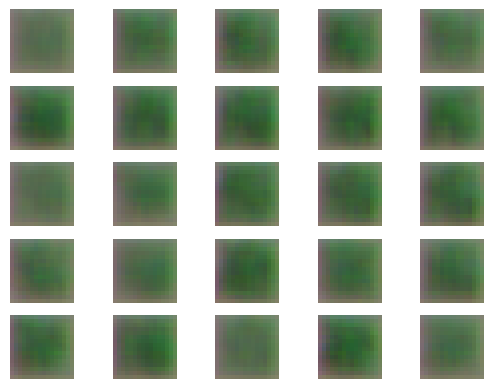

[1/300][0/32] 	Loss_D: 0.6449	Loss_G: -0.3326	D(x): 0.7916	D(G(z)): 0.3126
[2/300][0/32] 	Loss_D: 0.4384	Loss_G: -0.1397	D(x): 0.8594	D(G(z)): 0.1813
[3/300][0/32] 	Loss_D: 0.1152	Loss_G: -0.0426	D(x): 0.9675	D(G(z)): 0.0516
[4/300][0/32] 	Loss_D: 0.3372	Loss_G: -0.0104	D(x): 0.8834	D(G(z)): 0.0821
[5/300][0/32] 	Loss_D: 0.4996	Loss_G: -0.0984	D(x): 0.7934	D(G(z)): 0.1009
[6/300][0/32] 	Loss_D: 0.0984	Loss_G: -0.0236	D(x): 0.9441	D(G(z)): 0.0240
[7/300][0/32] 	Loss_D: 0.0627	Loss_G: -0.0234	D(x): 0.9757	D(G(z)): 0.0293
[8/300][0/32] 	Loss_D: 0.1273	Loss_G: -0.0253	D(x): 0.9795	D(G(z)): 0.0900
[9/300][0/32] 	Loss_D: 0.6258	Loss_G: -0.0002	D(x): 0.8095	D(G(z)): 0.0000
[10/300][0/32] 	Loss_D: 0.5198	Loss_G: -0.0458	D(x): 0.9072	D(G(z)): 0.1505
[11/300][0/32] 	Loss_D: 0.1213	Loss_G: -0.0253	D(x): 0.9399	D(G(z)): 0.0264
[12/300][0/32] 	Loss_D: 0.0153	Loss_G: -0.0068	D(x): 0.9930	D(G(z)): 0.0072
[13/300][0/32] 	Loss_D: 0.0034	Loss_G: -0.0026	D(x): 0.9993	D(G(z)): 0.0027
[14/300][0/32] 	Loss_

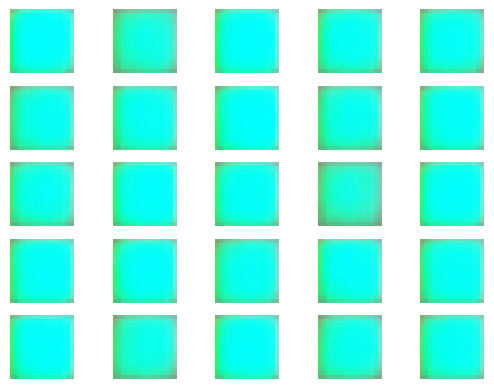

[26/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0002	D(x): 1.0000	D(G(z)): 0.0002
[27/300][0/32] 	Loss_D: 0.0003	Loss_G: -0.0002	D(x): 0.9999	D(G(z)): 0.0002
[28/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0001	D(x): 0.9999	D(G(z)): 0.0001
[29/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0001	D(x): 0.9999	D(G(z)): 0.0001
[30/300][0/32] 	Loss_D: 0.0004	Loss_G: -0.0001	D(x): 0.9997	D(G(z)): 0.0001
[31/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0001	D(x): 1.0000	D(G(z)): 0.0001
[32/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0001	D(x): 0.9999	D(G(z)): 0.0001
[33/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0001	D(x): 0.9999	D(G(z)): 0.0001
[34/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0001	D(x): 1.0000	D(G(z)): 0.0001
[35/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0001	D(x): 1.0000	D(G(z)): 0.0001
[36/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0001	D(x): 0.9998	D(G(z)): 0.0001
[37/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0001	D(x): 0.9998	D(G(z)): 0.0001
[38/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0001	D(x): 1.0000	D(G(z)): 0.0001
[39/300][0/3

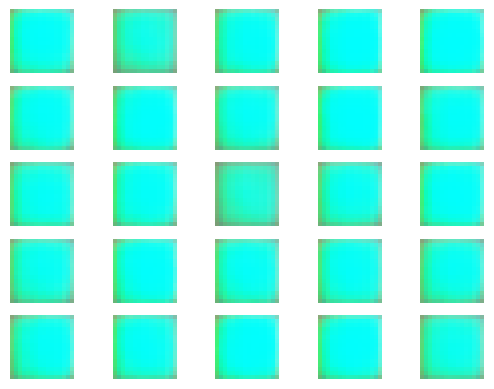

[51/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[52/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[53/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[54/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[55/300][0/32] 	Loss_D: 0.0002	Loss_G: -0.0000	D(x): 0.9999	D(G(z)): 0.0000
[56/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[57/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[58/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 0.9999	D(G(z)): 0.0000
[59/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[60/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[61/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[62/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[63/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[64/300][0/3

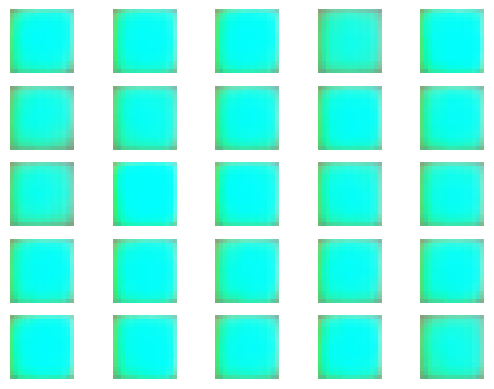

[76/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[77/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[78/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[79/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[80/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[81/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[82/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[83/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 0.9999	D(G(z)): 0.0000
[84/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[85/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[86/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[87/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[88/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[89/300][0/3

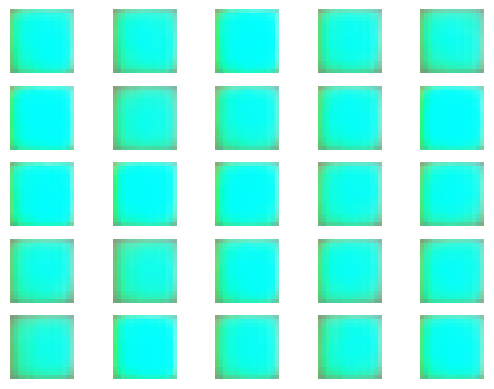

[101/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[102/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[103/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[104/300][0/32] 	Loss_D: 0.0001	Loss_G: -0.0000	D(x): 0.9999	D(G(z)): 0.0000
[105/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[106/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[107/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[108/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[109/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[110/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[111/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[112/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[113/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000

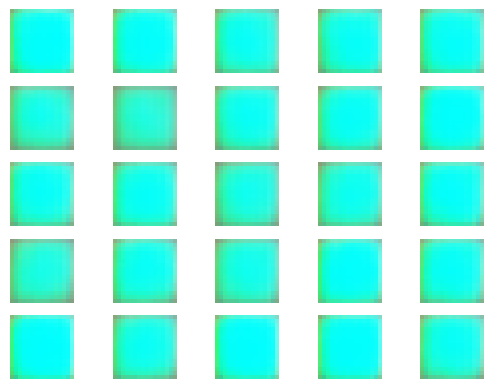

[126/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[127/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[128/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[129/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[130/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[131/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[132/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[133/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[134/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[135/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[136/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[137/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[138/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000

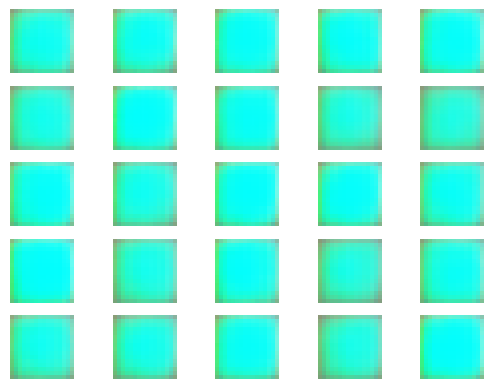

[151/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[152/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[153/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[154/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[155/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[156/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[157/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[158/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[159/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[160/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[161/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[162/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[163/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000

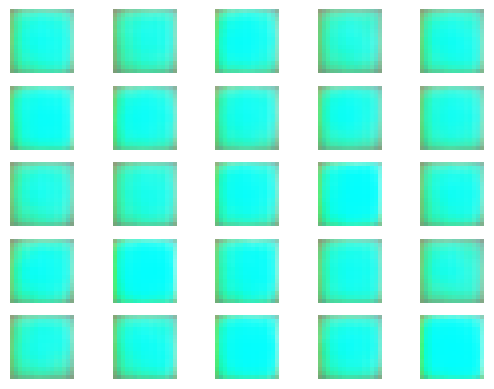

[176/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[177/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[178/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[179/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[180/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[181/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[182/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[183/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[184/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[185/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[186/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[187/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[188/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000

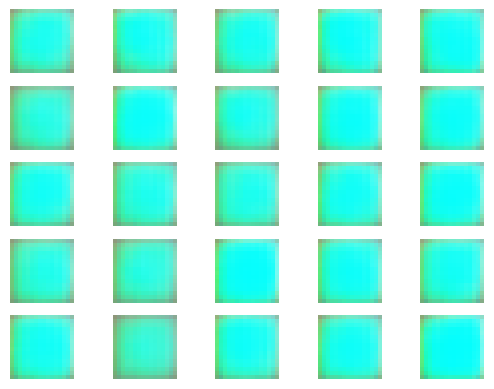

[201/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[202/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[203/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[204/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[205/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[206/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[207/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000
[208/300][0/32] 	Loss_D: 0.0000	Loss_G: -0.0000	D(x): 1.0000	D(G(z)): 0.0000


In [ ]:
# Training Loop

img_list = []
G_losses = []
D_losses = []

sample_interval = 25

print("Starting Training")

for epoch in range(n_epochs):

    for i, data in enumerate(cifar_train_loader, 0):   # changed loader

        for iter_inner in range(0, n_iters_inner):

            ############################
            ### Train discriminator
            ############################

            disc_model.zero_grad()

            # Real images (CIFAR: 3x32x32)
            true_imgs = data[0].to(device)
            batch_size_curr = true_imgs.size(0)

            true_labels = torch.ones(batch_size_curr, device=device)

            d_output_true = disc_model(true_imgs).view(-1)
            d_loss_true = bce_criterion(d_output_true, true_labels)

            d_loss_true.backward()
            disc_true_value = d_output_true.mean().item()

            # ---- Fake batch ----
            z_latent_noise = torch.randn(batch_size_curr, z_dim, device=device)
            fake_imgs = gen_model(z_latent_noise)

            fake_labels = torch.zeros(batch_size_curr, device=device)

            disc_output_fake = disc_model(fake_imgs.detach()).view(-1)
            disc_loss_fake = bce_criterion(disc_output_fake, fake_labels)

            disc_loss_fake.backward()
            disc_fake_value = disc_output_fake.mean().item()

            optimizer_disc.step()

            d_loss_total = d_loss_true + disc_loss_fake

        ############################
        ### Train generator
        ############################

        gen_model.zero_grad()

        disc_gen_output_fake = disc_model(fake_imgs).view(-1)
        g_loss = loss_fn_gen(disc_gen_output_fake)

        g_loss.backward()
        optimizer_gen.step()

        # Print stats
        if i % 200 == 0:
            print('[%d/%d][%d/%d] \tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f'
                  % (epoch, n_epochs, i, len(cifar_train_loader),
                     d_loss_total.item(), g_loss.item(),
                     disc_true_value, disc_fake_value))

        G_losses.append(g_loss.item())
        D_losses.append(d_loss_total.item())

    # Sample images
    if epoch % sample_interval == 0:
        sample_images(gen_model, z_dim, rand_seed=30)

# Final samples
sample_images(gen_model, z_dim, rand_seed=30)


## 